# TMDB Movie Industry Analysis
### What drives box office performance? An exploratory analysis of 10,000+ films.

**Dataset:** TMDb Movie Dataset — 10,866 films spanning 1960–2015
**Tools:** Python · pandas · seaborn · matplotlib

---

## Business Context

Film studios commit hundreds of millions of dollars before knowing whether a project will succeed.
Understanding the patterns behind box office performance — which genres resonate with audiences,
which budget ranges deliver the best returns, when to release — can meaningfully improve
production and distribution decisions.

This analysis explores 10,866 films from the TMDb dataset to answer five specific questions:

1. **Which genres earn the highest audience ratings?**
2. **Which genres generate the best return on investment?**
3. **What is the true relationship between production budget and box office revenue?**
4. **Does release timing affect box office performance?**
5. **How concentrated is revenue across the industry?**

---

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Consistent visual theme across all charts
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

os.makedirs('images', exist_ok=True)

print("Setup complete.")

Setup complete.


In [2]:
df = pd.read_csv('data/tmdb-movies.csv')

print(f"Loaded: {df.shape[0]:,} films x {df.shape[1]} columns")
print(f"Release years: {int(df['release_year'].min())} - {int(df['release_year'].max())}")
df.head(3)

Loaded: 10,866 films x 21 columns
Release years: 1960 - 2015


,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08


---
## 1. Data Quality Assessment

Before any analysis, it's critical to understand what the data contains — and what it doesn't.

In [3]:
# Missing values by column
missing = df.isnull().sum()
missing = missing[missing > 0].rename('missing_count').to_frame()
missing['missing_%'] = (missing['missing_count'] / len(df) * 100).round(1)
missing.sort_values('missing_%', ascending=False)

,missing_count,missing_%
homepage,7930,73.0
tagline,2824,26.0
keywords,1493,13.7
production_companies,1030,9.5
cast,76,0.7
director,44,0.4
genres,23,0.2
imdb_id,10,0.1
overview,4,0.0


In [4]:
# Zero values in financial columns are the bigger data quality issue.
# These are not genuinely zero-budget or zero-revenue films — the data was simply not reported.
n_zero_budget = (df['budget'] == 0).sum()
n_zero_revenue = (df['revenue'] == 0).sum()

print(f"Films with budget  = $0:  {n_zero_budget:,}  ({n_zero_budget / len(df) * 100:.0f}% of dataset)")
print(f"Films with revenue = $0:  {n_zero_revenue:,}  ({n_zero_revenue / len(df) * 100:.0f}% of dataset)")
print()
print("These are treated as missing data, not real values.")
print("They will be excluded from all financial analysis.")

Films with budget  = $0:  5,696  (52% of dataset)
Films with revenue = $0:  6,016  (55% of dataset)

These are treated as missing data, not real values.
They will be excluded from all financial analysis.


---
## 2. Data Cleaning

| Decision | Reason |
|---|---|
| Remove 1 duplicate row | Exact duplicate detected |
| Drop `imdb_id`, `homepage`, `tagline`, `keywords` | High missing rate; not needed for this analysis |
| Parse `release_date` → month | Required for seasonality analysis |
| Filter `budget > 0` AND `revenue > 0` for financial subset | ~50% of rows lack financial data — including zeros would produce misleading results |
| Calculate ROI = (revenue − budget) / budget | Standard measure of financial efficiency |

**Two dataframes are used throughout:**
- **`df`** — 10,865 films (ratings, genres, release patterns)
- **`df_fin`** — films with complete financial data (all budget/revenue analysis)

In [5]:
# 1. Remove duplicate
df.drop_duplicates(inplace=True)

# 2. Drop high-missing columns not needed for analysis
df.drop(columns=['imdb_id', 'homepage', 'tagline', 'keywords'], inplace=True)

# 3. Parse release date and extract month for seasonality analysis
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_month'] = df['release_date'].dt.month

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['release_month_name'] = pd.Categorical(
    df['release_date'].dt.strftime('%b'),
    categories=month_order,
    ordered=True
)

# 4. Financial subset — only films with both budget AND revenue reported
df_fin = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()

# 5. Return on Investment
df_fin['roi'] = (df_fin['revenue'] - df_fin['budget']) / df_fin['budget']

print(f"Full dataset:      {len(df):,} films  (used for ratings, genres, release patterns)")
print(f"Financial subset:  {len(df_fin):,} films  (used for budget, revenue, and ROI analysis)")

Full dataset:      10,865 films  (used for ratings, genres, release patterns)
Financial subset:  3,854 films  (used for budget, revenue, and ROI analysis)


---
## 3. Analysis

### Q1 — Which genres earn the highest audience ratings?

Genres are stored as pipe-separated values (e.g. `Action|Adventure|Thriller`).
Each film is expanded into one row per genre to enable accurate per-genre comparisons.
Only genres with at least 50 films are included to ensure reliability.

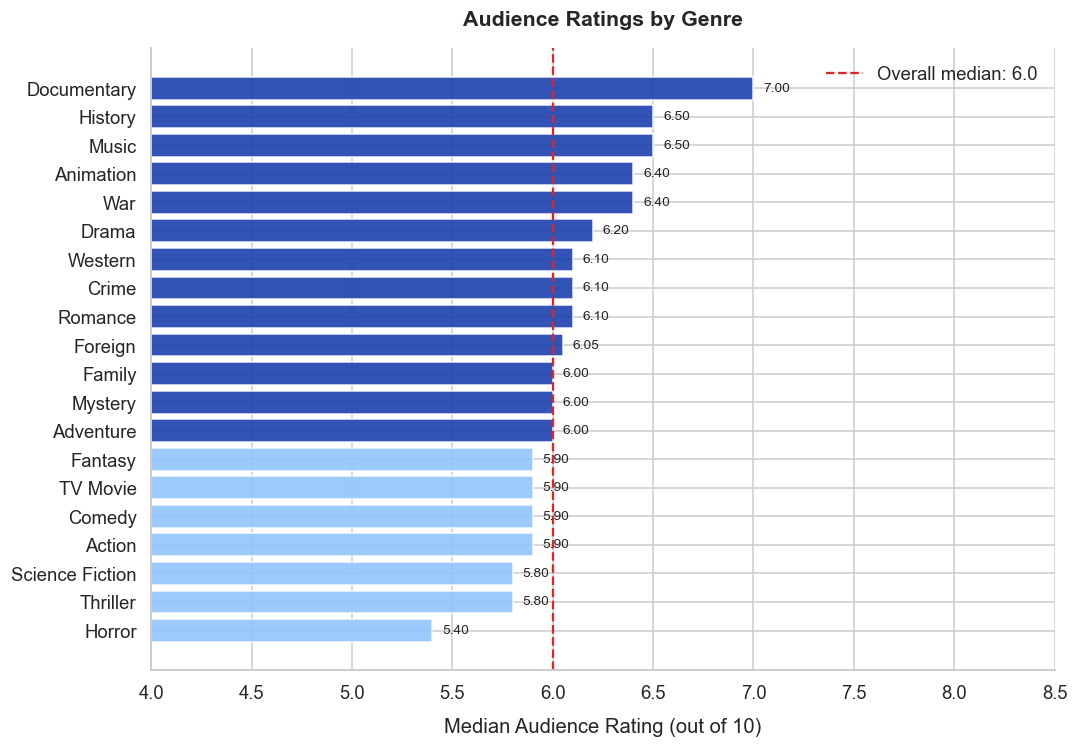

In [6]:
# Expand genres: one row per genre per film
genres_df = (
    df.assign(genre=df['genres'].str.split('|'))
    .explode('genre')
)
genres_df = genres_df[genres_df['genre'].notna() & (genres_df['genre'].str.strip() != '')]

# Median rating per genre (min. 50 films)
genre_ratings = (
    genres_df.groupby('genre')['vote_average']
    .agg(median='median', count='count')
    .query('count >= 50')
    .sort_values('median', ascending=True)
)

overall_median = df['vote_average'].median()

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#1e40af' if v >= overall_median else '#93c5fd' for v in genre_ratings['median']]
ax.barh(genre_ratings.index, genre_ratings['median'], color=colors, alpha=0.9)
ax.axvline(overall_median, color='#DC2626', linestyle='--', linewidth=1.5,
           label=f'Overall median: {overall_median:.1f}')

ax.set_xlabel('Median Audience Rating (out of 10)', labelpad=10)
ax.set_title('Audience Ratings by Genre', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(4, 8.5)
ax.legend(frameon=False)

for i, (idx, row) in enumerate(genre_ratings.iterrows()):
    ax.text(row['median'] + 0.05, i, f"{row['median']:.2f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('images/01_genre_ratings.png', bbox_inches='tight')
plt.show()

**Finding:** Documentary and History films consistently earn the highest audience ratings.
This reflects an engaged, self-selected viewership — audiences who seek out these genres
tend to rate them favourably. Horror and Thriller sit at the lower end, suggesting that
critical reception in these genres operates on different expectations than, say, drama.

For studios, this means genre selection involves a trade-off: niche, high-rated genres
attract audience goodwill, while mainstream genres trade critical scores for volume.

### Q2 — Which genres generate the best return on investment?

ROI is calculated as `(revenue − budget) / budget`. A value of 1.0 means the film
returned its budget in profit. The analysis uses only films with valid budget and revenue data.

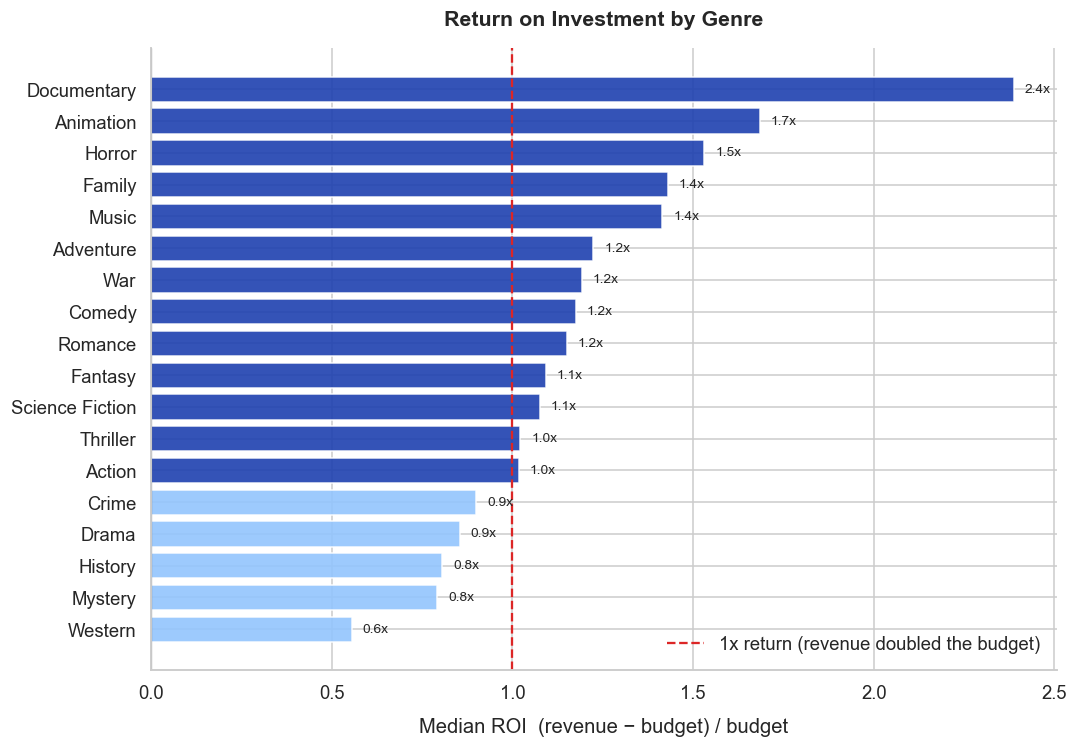

In [7]:
# Expand genres on the financial subset
genres_fin = (
    df_fin.assign(genre=df_fin['genres'].str.split('|'))
    .explode('genre')
)
genres_fin = genres_fin[genres_fin['genre'].notna() & (genres_fin['genre'].str.strip() != '')]

# Median ROI per genre (min. 20 films with financial data)
genre_roi = (
    genres_fin.groupby('genre')['roi']
    .agg(median_roi='median', count='count')
    .query('count >= 20')
    .sort_values('median_roi', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#1e40af' if r >= 1.0 else '#93c5fd' for r in genre_roi['median_roi']]
ax.barh(genre_roi.index, genre_roi['median_roi'], color=colors, alpha=0.9)
ax.axvline(1.0, color='#DC2626', linestyle='--', linewidth=1.5,
           label='1x return (revenue doubled the budget)')
ax.axvline(0, color='gray', linewidth=0.8)

ax.set_xlabel('Median ROI  (revenue − budget) / budget', labelpad=10)
ax.set_title('Return on Investment by Genre', fontsize=14, fontweight='bold', pad=15)
ax.legend(frameon=False)

for i, (idx, row) in enumerate(genre_roi.iterrows()):
    ax.text(row['median_roi'] + 0.03, i, f"{row['median_roi']:.1f}x", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('images/02_genre_roi.png', bbox_inches='tight')
plt.show()

**Finding:** Animation and Adventure lead on ROI — driven by franchise potential,
merchandise, and strong international appeal. The more surprising result is Horror:
despite its lower audience ratings (Q1), Horror consistently delivers strong financial
returns because production costs are far lower than blockbuster genres.

This disconnect between critical reception and financial efficiency is one of the
industry's most important dynamics. High ratings don't automatically translate to
high returns, and vice versa.

### Q3 — What is the true relationship between production budget and revenue?

Both axes use a log scale to handle the extreme range of values (from $10K to $400M+ budgets).
The dashed line marks break-even — where revenue equals the production budget.

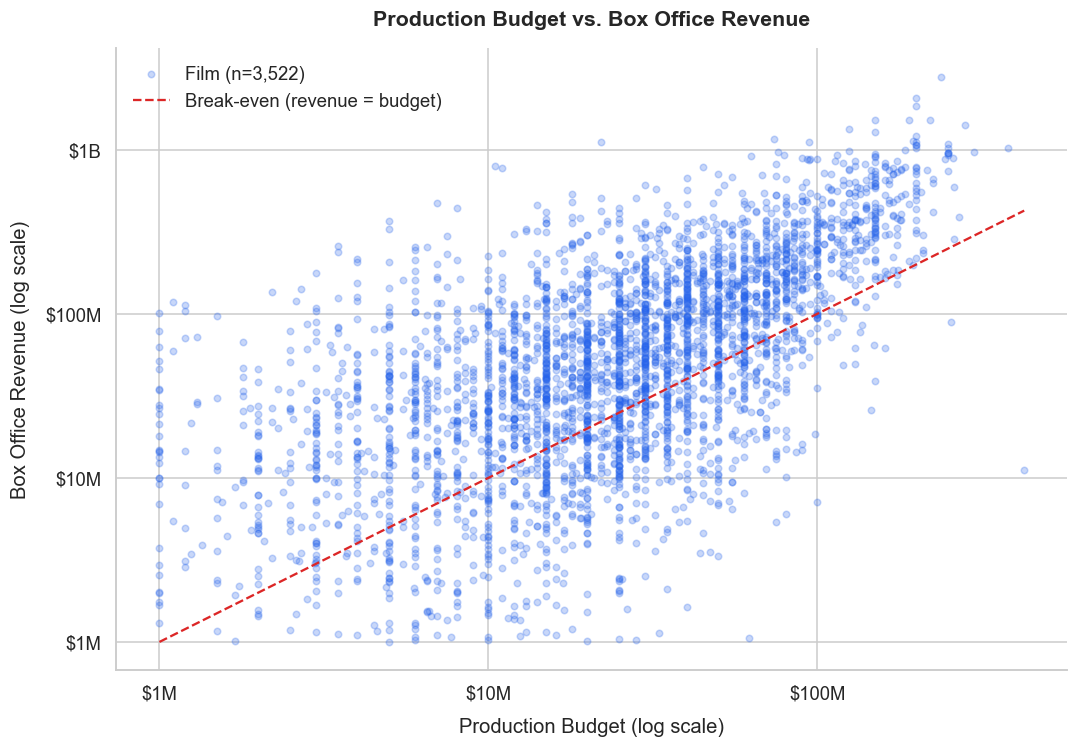

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

# Filter to films with reported budgets >= $1M for a cleaner log-scale chart
plot_data = df_fin[(df_fin['budget'] >= 1e6) & (df_fin['revenue'] >= 1e6)]

ax.scatter(
    plot_data['budget'] / 1e6,
    plot_data['revenue'] / 1e6,
    alpha=0.25, s=18, color='#2563EB', label=f'Film (n={len(plot_data):,})'
)

# Break-even line: revenue = budget
b_range = [plot_data['budget'].min() / 1e6, plot_data['budget'].max() / 1e6]
ax.plot(b_range, b_range,
        color='#DC2626', linestyle='--', linewidth=1.5,
        label='Break-even (revenue = budget)', zorder=5)

ax.set_xscale('log')
ax.set_yscale('log')

def dollar_fmt(x, _):
    if x >= 1000:
        return f'${x / 1000:.0f}B'
    return f'${x:.0f}M'

ax.xaxis.set_major_formatter(mtick.FuncFormatter(dollar_fmt))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(dollar_fmt))
ax.set_xlabel('Production Budget (log scale)', labelpad=10)
ax.set_ylabel('Box Office Revenue (log scale)', labelpad=10)
ax.set_title('Production Budget vs. Box Office Revenue', fontsize=14, fontweight='bold', pad=15)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('images/03_budget_vs_revenue.png', bbox_inches='tight')
plt.show()

**Finding:** There is a broad positive relationship — larger budgets tend to produce
larger revenues. But the spread around the break-even line is enormous at every budget level.

Points **above** the dashed line are profitable films; points **below** lost money.
High-budget productions cluster near or below break-even more often than the narrative
of "blockbusters always win" suggests. Some of the strongest returns in the dataset
came from mid-budget films ($20–80M range), where the upside potential is still
significant but the downside risk is more contained.

### Q4 — Does release timing affect box office performance?

Median revenue is used rather than mean to reduce the distorting effect of a small number
of blockbusters in any given month.

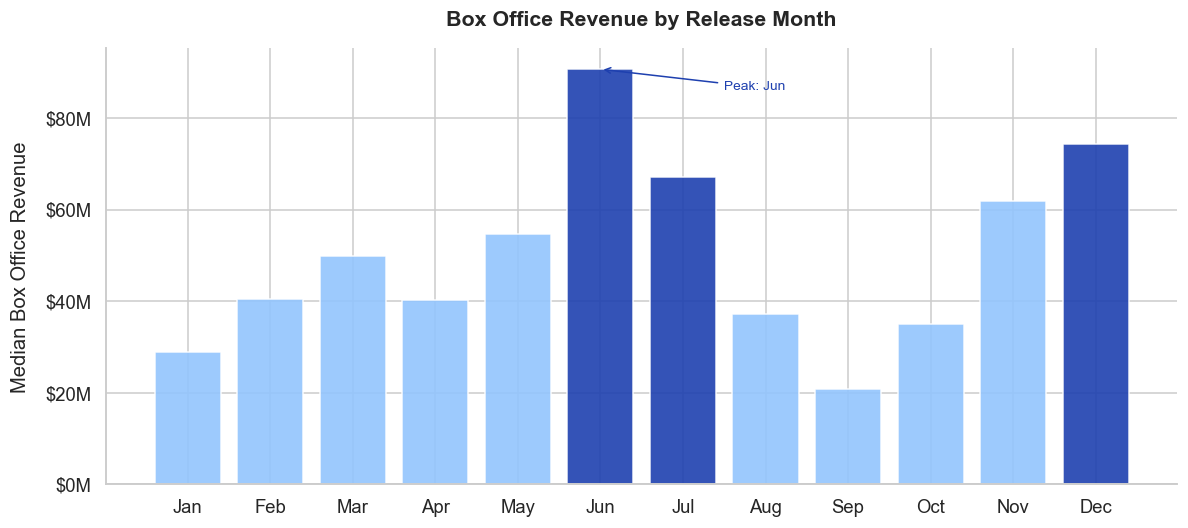

In [9]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_rev = (
    df_fin
    .assign(month_name=df_fin['release_date'].dt.strftime('%b'))
    .groupby('month_name')['revenue']
    .median()
    .reindex(month_order)
    / 1e6
)

peak_month = monthly_rev.idxmax()
colors = ['#1e40af' if m in [peak_month, 'Jun', 'Jul', 'Dec'] else '#93c5fd'
          for m in monthly_rev.index]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(monthly_rev.index, monthly_rev.values, color=colors, alpha=0.9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.set_ylabel('Median Box Office Revenue', labelpad=10)
ax.set_title('Box Office Revenue by Release Month', fontsize=14, fontweight='bold', pad=15)

# Annotate peak
ax.annotate(f'Peak: {peak_month}',
            xy=(month_order.index(peak_month), monthly_rev[peak_month]),
            xytext=(month_order.index(peak_month) + 1.5, monthly_rev[peak_month] * 0.95),
            arrowprops=dict(arrowstyle='->', color='#1e40af'),
            fontsize=9, color='#1e40af')

plt.tight_layout()
plt.savefig('images/04_release_timing.png', bbox_inches='tight')
plt.show()

**Finding:** Summer (May–July) and the holiday window (November–December) are
consistently the strongest release periods. January, September, and October are
the weakest — historically used for films with lower commercial expectations.

This pattern reflects studio strategy as much as audience behaviour: studios
deliberately release their highest-investment productions in these peak windows,
creating a self-reinforcing cycle. Releasing outside peak windows carries
measurable revenue risk unless the film has a specific audience that doesn't
depend on opening-weekend competition.

### Q5 — How concentrated is revenue across the industry?

A Lorenz-style cumulative revenue curve shows how evenly (or unevenly)
box office revenue is distributed across all films in the dataset.

Top 10% of films (385 films) account for 48.6% of total revenue
Top 25% of films (963 films) account for 74.2% of total revenue
Top 50% of films (1,927 films) account for 92.5% of total revenue


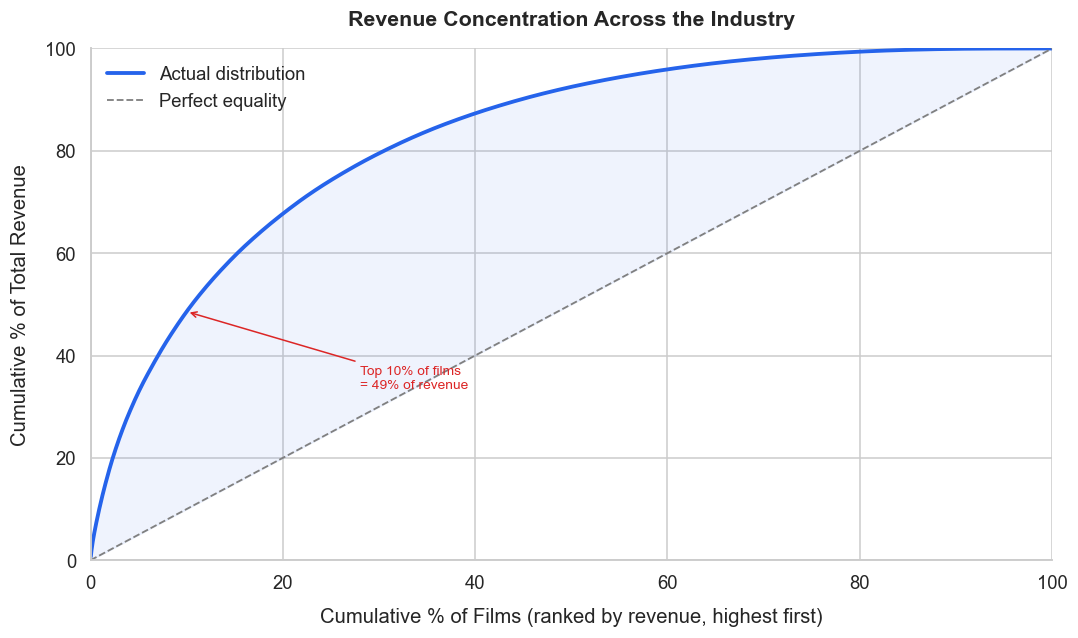

In [10]:
# Sort films by revenue, compute cumulative share
rev_sorted = df_fin['revenue'].sort_values(ascending=False).reset_index(drop=True)
rev_cumsum = (rev_sorted.cumsum() / rev_sorted.sum() * 100)
n_films = len(rev_sorted)
pct_films = np.arange(1, n_films + 1) / n_films * 100

# Print milestones
for pct in [10, 25, 50]:
    idx = int(pct / 100 * n_films)
    print(f"Top {pct:>2}% of films ({idx:,} films) account for "
          f"{rev_cumsum.iloc[idx - 1]:.1f}% of total revenue")

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(pct_films, rev_cumsum, color='#2563EB', linewidth=2.5, label='Actual distribution')
ax.plot([0, 100], [0, 100], color='gray', linestyle='--', linewidth=1.2,
        label='Perfect equality')
ax.fill_between(pct_films, rev_cumsum, pct_films, alpha=0.07, color='#2563EB')

# Annotate 10% mark
idx_10 = int(0.10 * n_films)
ax.annotate(
    f"Top 10% of films\n= {rev_cumsum.iloc[idx_10 - 1]:.0f}% of revenue",
    xy=(10, rev_cumsum.iloc[idx_10 - 1]),
    xytext=(28, rev_cumsum.iloc[idx_10 - 1] - 15),
    arrowprops=dict(arrowstyle='->', color='#DC2626'),
    fontsize=9, color='#DC2626'
)

ax.set_xlabel('Cumulative % of Films (ranked by revenue, highest first)', labelpad=10)
ax.set_ylabel('Cumulative % of Total Revenue', labelpad=10)
ax.set_title('Revenue Concentration Across the Industry', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('images/05_revenue_concentration.png', bbox_inches='tight')
plt.show()

**Finding:** The film industry follows a classic winner-take-all distribution.
A small fraction of films accounts for the vast majority of total revenue —
a pattern far more extreme than equal distribution would suggest.

This has two important implications:
- **For analysts**: using *average* revenue as a benchmark significantly overstates
  typical film performance. Median is a far more honest measure.
- **For studios**: the potential upside of a blockbuster is enormous, but the
  *median* film earns a fraction of what the industry average implies.

---
## 4. Key Findings

| # | Finding | Implication |
|---|---|---|
| 1 | **Documentary and History** earn the highest audience ratings | Genre shapes perceived quality, not just commercial performance |
| 2 | **Animation and Horror** deliver the strongest ROI | Horror's low cost base makes it financially efficient despite lower ratings |
| 3 | **High budget ≠ high return** | The break-even line shows many large-budget films underperform; mid-budget can outperform |
| 4 | **Summer and holiday windows dominate** | Releasing outside peak periods carries measurable revenue risk |
| 5 | **Revenue is highly concentrated** | Top 10% of films drive the majority of industry revenue — median performance is far below average |

---
## 5. Limitations

- **Missing financial data**: approximately half of all films had no reported budget or revenue.
  The financial subset likely skews toward larger, higher-profile productions.
- **Correlation vs. causation**: higher summer revenue partly reflects studios *choosing* to
  release their best films then — not purely a timing effect on audiences.
- **Genre overlap**: films span multiple genres and each is counted once per genre,
  which overstates some genre-level sample sizes.
- **Dataset ends at 2015**: streaming economics have fundamentally changed industry
  dynamics since then. These findings apply to the theatrical model.
- **No marketing spend data**: production budget is only part of a film's total cost.
  Marketing budgets (often matching or exceeding production budgets) are not captured here.